In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import norm

In [3]:
# path = "Dados_da_Região_Norte/dados_A215_H_2008-06-13_2024-01-01.csv"

path = "data/dados_A215_H_2008-06-13_2024-01-01.csv"

df = pd.read_csv(path, header = 9, sep =';')
df.drop(columns= ['Unnamed: 22'], axis =1,inplace = True)
df.replace(to_replace = ',', value = '.', regex = True, inplace =True)
df = df.apply(pd.to_numeric, errors = 'ignore')
df['Hora Medicao'] = df['Hora Medicao']/100
df['Hora Medicao'] = df['Hora Medicao'].astype(int).astype(str).str.zfill(2)
df['Hora Medicao'] = pd.to_datetime(df['Hora Medicao'], format='%H').dt.time
df['Data_Hora'] = pd.to_datetime(df['Data Medicao'] +' '+ df['Hora Medicao'].astype(str))
df.set_index('Data_Hora', inplace= True)
df.dropna(inplace = True)
df['hour']= df.index.hour
df = df[(df.index.hour >= 12) & (df.index.hour <=20)]
df.drop(columns=['Data Medicao', 'Hora Medicao', 'hour'], inplace = True)
df.sort_index(inplace =True)
df['SMA_5'] = df['RADIACAO GLOBAL(Kj/m²)'].rolling(window=5,center =True).mean()
df['VEL_VENTO_km_h'] = df['VENTO, VELOCIDADE HORARIA(m/s)'] * 3.6
df['ST'] = 33 + (10 * np.sqrt(df['VEL_VENTO_km_h']) + 10.45 - df['VEL_VENTO_km_h']) * (df['TEMPERATURA DO AR - BULBO SECO, HORARIA(°C)'] - 33) / 22
df.dropna(inplace =True)
# df.drop(columns=['ST', 'SMA_5', 'VEL_VENTO_km_h'], inplace = True)

columns_translation = {
    'PRECIPITACAO TOTAL, HORARIO(mm)': 'TOTAL PRECIPITATION, HOURLY (mm)',
    'PRESSAO ATMOSFERICA AO NIVEL DA ESTACAO, HORARIA(mB)': 'ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY (mB)',
    'PRESSAO ATMOSFERICA REDUZIDA NIVEL DO MAR, AUT(mB)': 'ATMOSPHERIC PRESSURE REDUCED TO SEA LEVEL, AUT (mB)',
    'PRESSAO ATMOSFERICA MAX.NA HORA ANT. (AUT)(mB)': 'ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR (AUT) (mB)',
    'PRESSAO ATMOSFERICA MIN. NA HORA ANT. (AUT)(mB)': 'ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR (AUT) (mB)',
    'RADIACAO GLOBAL(Kj/m²)': 'GLOBAL RADIATION (Kj/m²)',
    'TEMPERATURA DA CPU DA ESTACAO(°C)': 'STATION CPU TEMPERATURE (°C)',
    'TEMPERATURA DO AR - BULBO SECO, HORARIA(°C)': 'AIR TEMPERATURE - DRY BULB, HOURLY (°C)',
    'TEMPERATURA DO PONTO DE ORVALHO(°C)': 'DEW POINT TEMPERATURE (°C)',
    'TEMPERATURA MAXIMA NA HORA ANT. (AUT)(°C)': 'MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TEMPERATURA MINIMA NA HORA ANT. (AUT)(°C)': 'MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TEMPERATURA ORVALHO MAX. NA HORA ANT. (AUT)(°C)': 'MAXIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TEMPERATURA ORVALHO MIN. NA HORA ANT. (AUT)(°C)': 'MINIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
    'TENSAO DA BATERIA DA ESTACAO(V)': 'STATION BATTERY VOLTAGE (V)',
    'UMIDADE REL. MAX. NA HORA ANT. (AUT)(%)': 'RELATIVE HUMIDITY MAX. IN THE PREVIOUS HOUR (AUT) (%)',
    'UMIDADE REL. MIN. NA HORA ANT. (AUT)(%)': 'RELATIVE HUMIDITY MIN. IN THE PREVIOUS HOUR (AUT) (%)',
    'UMIDADE RELATIVA DO AR, HORARIA(%)': 'AIR RELATIVE HUMIDITY, HOURLY (%)',
    'VENTO, DIRECAO HORARIA (gr)(° (gr))': 'WIND, HOURLY DIRECTION (gr) (° (gr))',
    'VENTO, RAJADA MAXIMA(m/s)': 'WIND, MAXIMUM GUST (m/s)',
    'VENTO, VELOCIDADE HORARIA(m/s)': 'WIND, HOURLY SPEED (m/s)'
}
df.rename(columns=columns_translation, inplace=True)
k = 3
media = df['GLOBAL RADIATION (Kj/m²)'].mean()
desvio_padrao = df['GLOBAL RADIATION (Kj/m²)'].std()
limite_inferior = media - k * desvio_padrao
limite_superior = media + k * desvio_padrao

df = df[(df['GLOBAL RADIATION (Kj/m²)'] >= limite_inferior) & (df['GLOBAL RADIATION (Kj/m²)'] <= limite_superior)]
df.to_parquet('FormatDataSalinas.gzip', compression = 'gzip')


/tmp/ipykernel_31002/4198259539.py:8: FutureWarning: errors='ignore' is deprecated and will raise in a future version. Use to_numeric without passing `errors` and catch exceptions explicitly instead
  df = df.apply(pd.to_numeric, errors = 'ignore')


In [6]:
negativo = (df < 0).sum().sum()
int(negativo)

58

In [4]:
y = df['GLOBAL RADIATION (Kj/m²)']
X = df.drop(columns = 'GLOBAL RADIATION (Kj/m²)')
print(f'Tamanho da Base de dados: {len(X)}')

size = 0.8
train_size = int(size * len(y))
print(f"Tamanho da base de treino: {size}")

X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]
print(f"Treino: {len(X_train)}, Teste: {len(X_test)}")

Tamanho da Base de dados: 33386
Tamanho da base de treino: 0.8
Treino: 26708, Teste: 6678


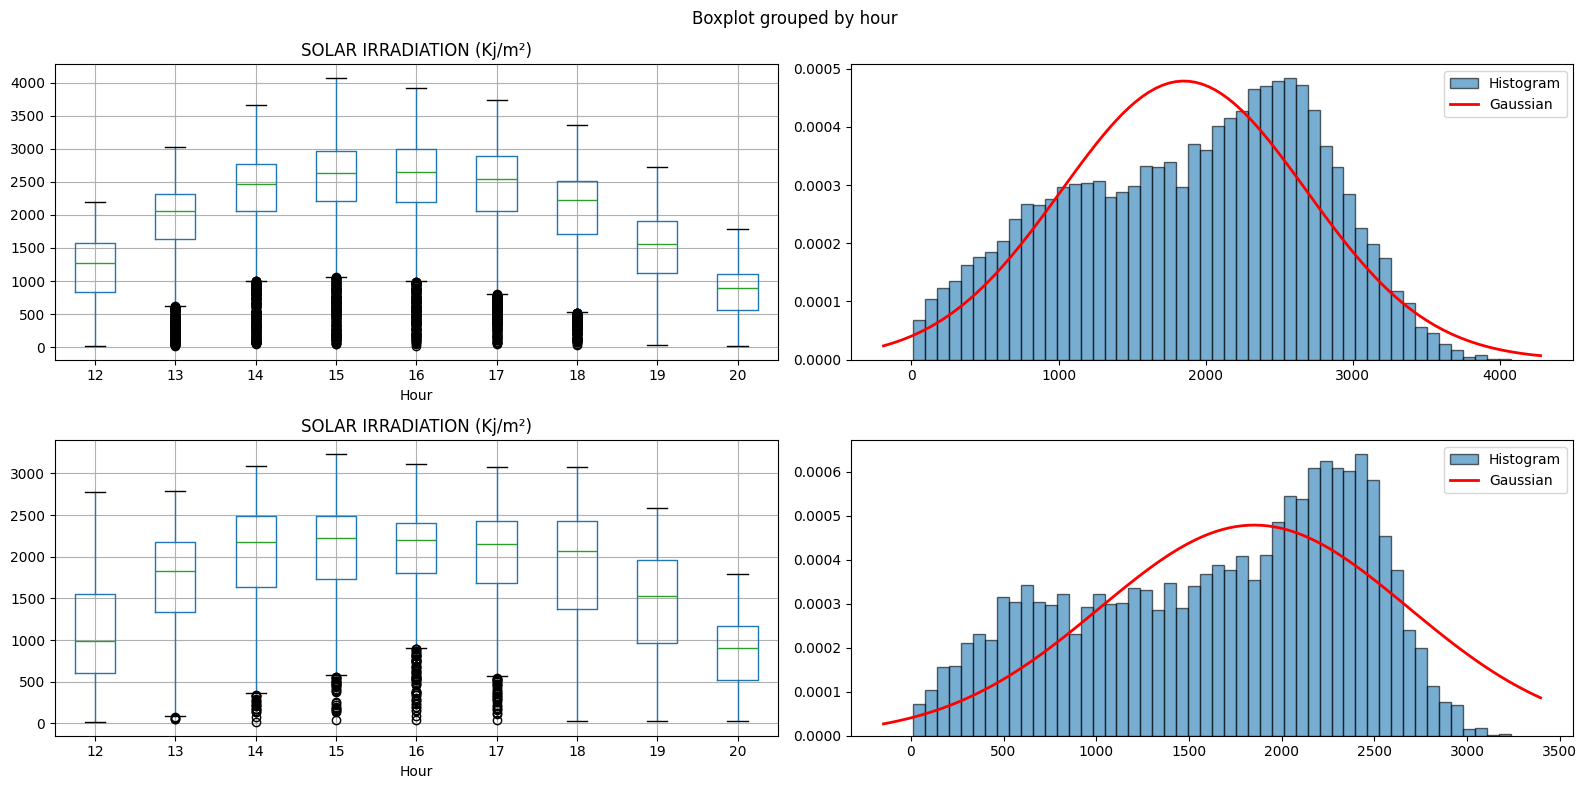

In [5]:
fig, ax = plt.subplots(2,2,figsize=(16,8))
tempdf = y_train.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdf.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdf['hour'] = tempdf['Data_Hora'].dt.hour
tempdf.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[0,0])
ax[0,0].set_xlabel('Hour')
ax[0,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[0,1].hist(tempdf['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[0,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
ax[0,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[0,1].legend()
tempdftest = y_test.rename('GLOBAL RADIATION (Kj/m²)').reset_index()
tempdftest.rename(columns={'index': 'Data_Hora'}, inplace=True)
tempdftest['hour'] = tempdftest['Data_Hora'].dt.hour
tempdftest.boxplot(column='GLOBAL RADIATION (Kj/m²)',by= 'hour', ax =ax[1,0])
ax[1,0].set_xlabel('Hour')
ax[1,0].set_title('SOLAR IRRADIATION (Kj/m²)')

ax[1,1].hist(tempdftest['GLOBAL RADIATION (Kj/m²)'],density=True,alpha=0.6, bins= 50,label='Histogram', edgecolor = 'black')
m = df['GLOBAL RADIATION (Kj/m²)'].mean()
std = df['GLOBAL RADIATION (Kj/m²)'].std()
xmin,xmax=ax[1,1].get_xlim()
x = np.linspace(xmin,xmax,100)
p = norm.pdf(x,m,std)
# df.drop(columns=['hour'],inplace=True)
ax[1,1].plot(x,p,'r', linewidth=2,label ='Gaussian')
ax[1,1].legend()
plt.tight_layout()
plt.show()

In [6]:
df.head()

,"TOTAL PRECIPITATION, HOURLY (mm)","ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY (mB)","ATMOSPHERIC PRESSURE REDUCED TO SEA LEVEL, AUT (mB)",ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR (AUT) (mB),ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR (AUT) (mB),GLOBAL RADIATION (Kj/m²),STATION CPU TEMPERATURE (°C),"AIR TEMPERATURE - DRY BULB, HOURLY (°C)",DEW POINT TEMPERATURE (°C),MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C),...,STATION BATTERY VOLTAGE (V),RELATIVE HUMIDITY MAX. IN THE PREVIOUS HOUR (AUT) (%),RELATIVE HUMIDITY MIN. IN THE PREVIOUS HOUR (AUT) (%),"AIR RELATIVE HUMIDITY, HOURLY (%)","WIND, HOURLY DIRECTION (gr) (° (gr))","WIND, MAXIMUM GUST (m/s)","WIND, HOURLY SPEED (m/s)",SMA_5,VEL_VENTO_km_h,ST
Data_Hora,,,,,,,,,,,,,,,,,,,,,
2009-11-11 18:00:00,0.0,1005.0,1007.798616,1005.5,1005.0,2578.558,34.0,30.2,21.5,31.1,...,13.0,61.0,57.0,60.0,69.0,10.4,5.6,1576.0154,20.16,28.521287
2009-11-11 19:00:00,0.0,1004.7,1007.508907,1005.0,1004.7,1622.739,33.0,29.0,22.2,30.2,...,12.8,67.0,60.0,67.0,69.0,11.2,5.1,1860.5628,18.36,26.647533
2009-11-11 20:00:00,0.0,1004.9,1007.715064,1004.9,1004.6,558.002,31.0,28.4,22.5,29.1,...,12.4,71.0,67.0,71.0,77.0,9.7,4.6,1736.4820,16.56,25.768804
2009-11-12 12:00:00,0.0,1005.8,1008.606402,1005.9,1005.7,1422.736,30.0,29.6,22.8,29.9,...,12.9,71.0,67.0,67.0,70.0,9.0,4.2,1815.8866,15.12,27.712313
2009-11-12 13:00:00,0.0,1006.1,1008.901679,1006.1,1005.8,2500.375,32.0,30.2,22.6,30.6,...,13.1,68.0,63.0,64.0,66.0,8.6,4.1,2175.1726,14.76,28.658887


In [7]:
estacoes = {
    "verao":["12-21","03-19"],
    "inverno":["06-20","09-21"],
    "outono":["03-20","06-19"],
    "primavera":["09-22","12-20"]
}
# 20 Mar 2025 - 06:01h 	20 Jun 2025 - 23:42h 	22 Set 2025 - 15:19h 	21 Dez 2025 - 12:03h

In [8]:
estacoes

{'verao': ['12-21', '03-19'],
 'inverno': ['06-20', '09-21'],
 'outono': ['03-20', '06-19'],
 'primavera': ['09-22', '12-20']}

In [9]:
def estacao_do_ano(index_datetime):
    datas = index_datetime

    def determinar_estacao(data):
        ano = data.year
        if pd.Timestamp(f'{ano}-03-20') <= data < pd.Timestamp(f'{ano}-06-21'):
            return 'outono'
        elif pd.Timestamp(f'{ano}-06-21') <= data < pd.Timestamp(f'{ano}-09-23'):
            return 'inverno'
        elif pd.Timestamp(f'{ano}-09-23') <= data < pd.Timestamp(f'{ano}-12-21'):
            return 'primavera'
        else:
            return 'verão'

    return pd.Series([determinar_estacao(data) for data in datas], index=datas)


In [10]:
df['estacao'] = estacao_do_ano(df.index)

In [11]:
df.columns

Index(['TOTAL PRECIPITATION, HOURLY (mm)',
       'ATMOSPHERIC PRESSURE AT STATION LEVEL, HOURLY (mB)',
       'ATMOSPHERIC PRESSURE REDUCED TO SEA LEVEL, AUT (mB)',
       'ATMOSPHERIC PRESSURE MAX. IN THE PREVIOUS HOUR (AUT) (mB)',
       'ATMOSPHERIC PRESSURE MIN. IN THE PREVIOUS HOUR (AUT) (mB)',
       'GLOBAL RADIATION (Kj/m²)', 'STATION CPU TEMPERATURE (°C)',
       'AIR TEMPERATURE - DRY BULB, HOURLY (°C)', 'DEW POINT TEMPERATURE (°C)',
       'MAXIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'MINIMUM TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'MAXIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'MINIMUM DEW POINT TEMPERATURE IN THE PREVIOUS HOUR (AUT) (°C)',
       'STATION BATTERY VOLTAGE (V)',
       'RELATIVE HUMIDITY MAX. IN THE PREVIOUS HOUR (AUT) (%)',
       'RELATIVE HUMIDITY MIN. IN THE PREVIOUS HOUR (AUT) (%)',
       'AIR RELATIVE HUMIDITY, HOURLY (%)',
       'WIND, HOURLY DIRECTION (gr) (° (gr))', 'WIND, MAXIMUM GUST (m/s)'

In [12]:
df.drop(columns=["STATION BATTERY VOLTAGE (V)", "STATION CPU TEMPERATURE (°C)"], inplace=True)

In [ ]:
daily_radiation = df.pivot(index='date', columns=df['datetime'].dt.hour, values='radiation')